# Exploratory Data Analysis

In this notebook we explore two questions:
- How did year-to-year population change differ between males and females in Aruba from 2015 to 2023?
- How did these trends evolve before and after COVID-19?

**Data source:**  Central Bureau of Statistics (CBS) Aruba — population dataset (2015–2023).

---
**Import libraries and set database Path**

In [1]:
# Import libraries
import sqlite3
import pandas as pd
from pathlib import Path

 #Set Path
DB_PATH = Path("../outputs/db_files/aruba.db")
TABLE_NAME = "population_change_by_sex"

# Connect to SQLite
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", conn)

# Inspection of DataFrame
df.head()
df.dtypes
df.info()

# df Copy
df = df.copy()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sex            18 non-null     str    
 1   year           18 non-null     int64  
 2   population     18 non-null     float64
 3   annual_change  16 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 816.0 bytes


---
# SQLite query

In [2]:
# Pre-COVID years
with sqlite3.connect(DB_PATH) as conn:
    df_sql = pd.read_sql(
        """
        SELECT *
        FROM population_change_by_sex
        WHERE year BETWEEN 2015 AND 2019;
        """,
        conn
    )

df_sql

,sex,year,population,annual_change
0,Females,2015,57326.0,NaN
1,Females,2016,57357.0,31.0
2,Females,2017,57253.0,-104.0
3,Females,2018,57652.0,399.0
4,Females,2019,57726.0,74.0
5,Males,2015,51309.0,NaN
6,Males,2016,51462.0,153.0
7,Males,2017,51399.0,-63.0
8,Males,2018,51512.0,113.0
9,Males,2019,51515.0,3.0


In [3]:
# COVID period
with sqlite3.connect(DB_PATH) as conn:
    df_sql = pd.read_sql(
        """
        SELECT *
        FROM population_change_by_sex
        WHERE year BETWEEN 2020 AND 2021;
        """,
        conn
    )

df_sql

,sex,year,population,annual_change
0,Females,2020,57002.0,-724.0
1,Females,2021,56804.0,-198.0
2,Males,2020,50930.0,-585.0
3,Males,2021,50664.0,-266.0


In [4]:
# Post-COVID, population recovery
with sqlite3.connect(DB_PATH) as conn:
    df_sql = pd.read_sql(
        """
        SELECT *
        FROM population_change_by_sex
        WHERE year BETWEEN 2022 AND 2023;
        """,
        conn
    )

df_sql

,sex,year,population,annual_change
0,Females,2022,56712.0,-92.0
1,Females,2023,57007.0,295.0
2,Males,2022,50440.0,-224.0
3,Males,2023,50559.0,119.0


In [5]:
def label_period(year):
    if 2015 <= year <= 2019:
        return "pre-COVID"
    elif 2020 <= year <= 2021:
        return "COVID"
    else:
        return "post-COVID"

df["period"] = df["year"].apply(label_period)

df

,sex,year,population,annual_change,period
0,Females,2015,57326.0,NaN,pre-COVID
1,Females,2016,57357.0,31.0,pre-COVID
2,Females,2017,57253.0,-104.0,pre-COVID
3,Females,2018,57652.0,399.0,pre-COVID
4,Females,2019,57726.0,74.0,pre-COVID
5,Females,2020,57002.0,-724.0,COVID
6,Females,2021,56804.0,-198.0,COVID
7,Females,2022,56712.0,-92.0,post-COVID
8,Females,2023,57007.0,295.0,post-COVID
9,Males,2015,51309.0,NaN,pre-COVID


In [6]:
df.groupby("sex")["annual_change"].apply(lambda s: s.isna().sum())

sex
Females    1
Males      1
Name: annual_change, dtype: int64

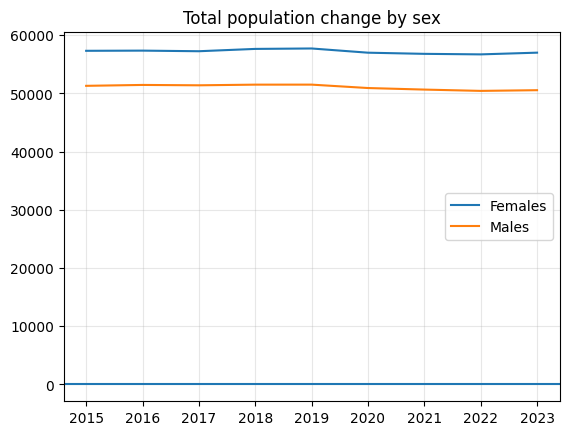

In [7]:
import matplotlib.pyplot as plt

for sex in df["sex"].unique():
    subset = df[df["sex"] == sex]
    plt.plot(subset["year"], subset["population"], label=sex)

plt.axhline(0)
plt.grid(alpha=0.30)
plt.legend()
plt.title("Total population change by sex")
plt.show()

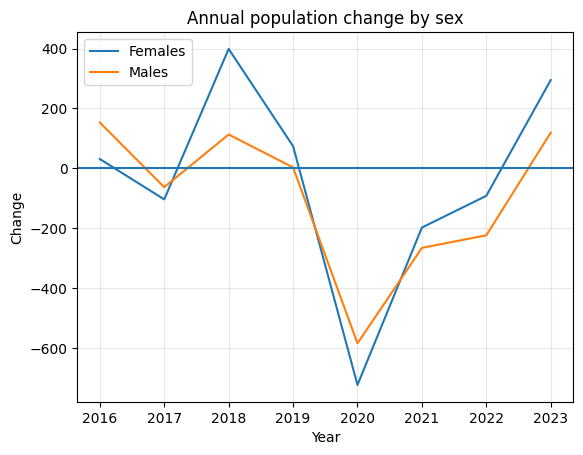

In [8]:
import matplotlib.pyplot as plt

for sex in df["sex"].unique():
    subset = df[df["sex"] == sex]
    plt.plot(subset["year"], subset["annual_change"], label=sex)

plt.axhline(0)
plt.legend()
plt.grid(alpha=0.30)
plt.title("Annual population change by sex")
plt.xlabel("Year")
plt.ylabel("Change")
plt.show()

In [9]:
df.groupby(["period", "sex"])["annual_change"].mean()

period      sex    
COVID       Females   -461.0
            Males     -425.5
post-COVID  Females    101.5
            Males      -52.5
pre-COVID   Females    100.0
            Males       51.5
Name: annual_change, dtype: float64